<a href="https://colab.research.google.com/github/sanskrutilanjewar83-del/Html-code-/blob/main/MLtask_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('task1.csv')

In [ ]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [ ]:
df['Date']=pd.to_datetime(df['Date'])

In [ ]:
duplicate = df.duplicated().sum()
missing = df.isnull().sum()

if duplicate > 0:
  df.drop_duplicates(inplace=True)
  print(f"Dropped {duplicate} duplicate rows.")

if missing.any():
  df.dropna(inplace=True)
  print("Dropped missing values.")

### Sales Trend Over Time

Let's visualize the `Total Amount` over `Date` to observe any trends or patterns in sales.

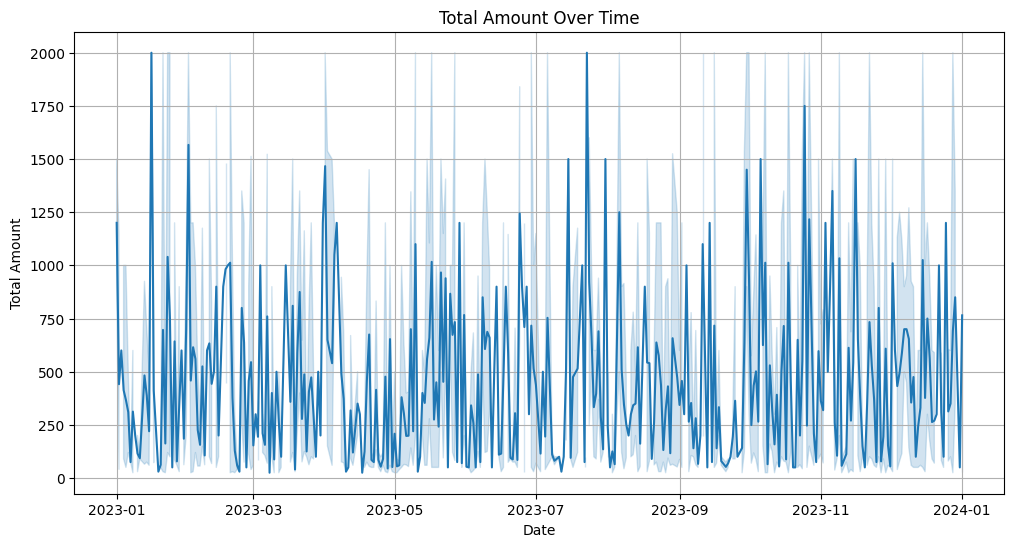

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='Total Amount')
plt.title('Total Amount Over Time')
plt.xlabel('Date')
plt.ylabel('Total Amount')
plt.grid(True)
plt.show()

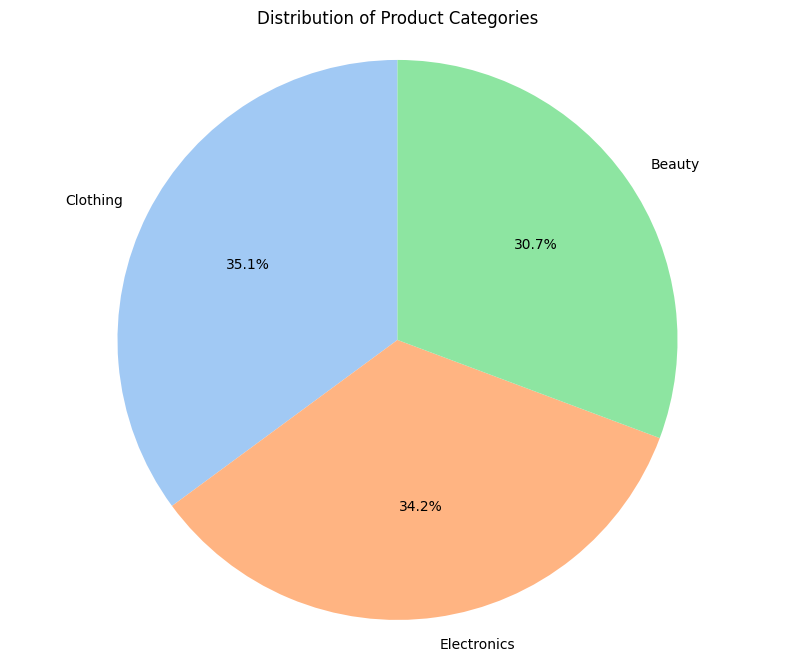

In [ ]:
category_counts = df['Product Category'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of Product Categories')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

## Univariate Analysis

Let's examine the distribution of individual variables to understand their characteristics.

In [ ]:
# Descriptive statistics for numerical columns
display(df.describe())

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


### Distribution of Numerical Features

We will visualize the distribution of numerical features using histograms and box plots to observe their shape, central tendency, spread, and potential outliers.

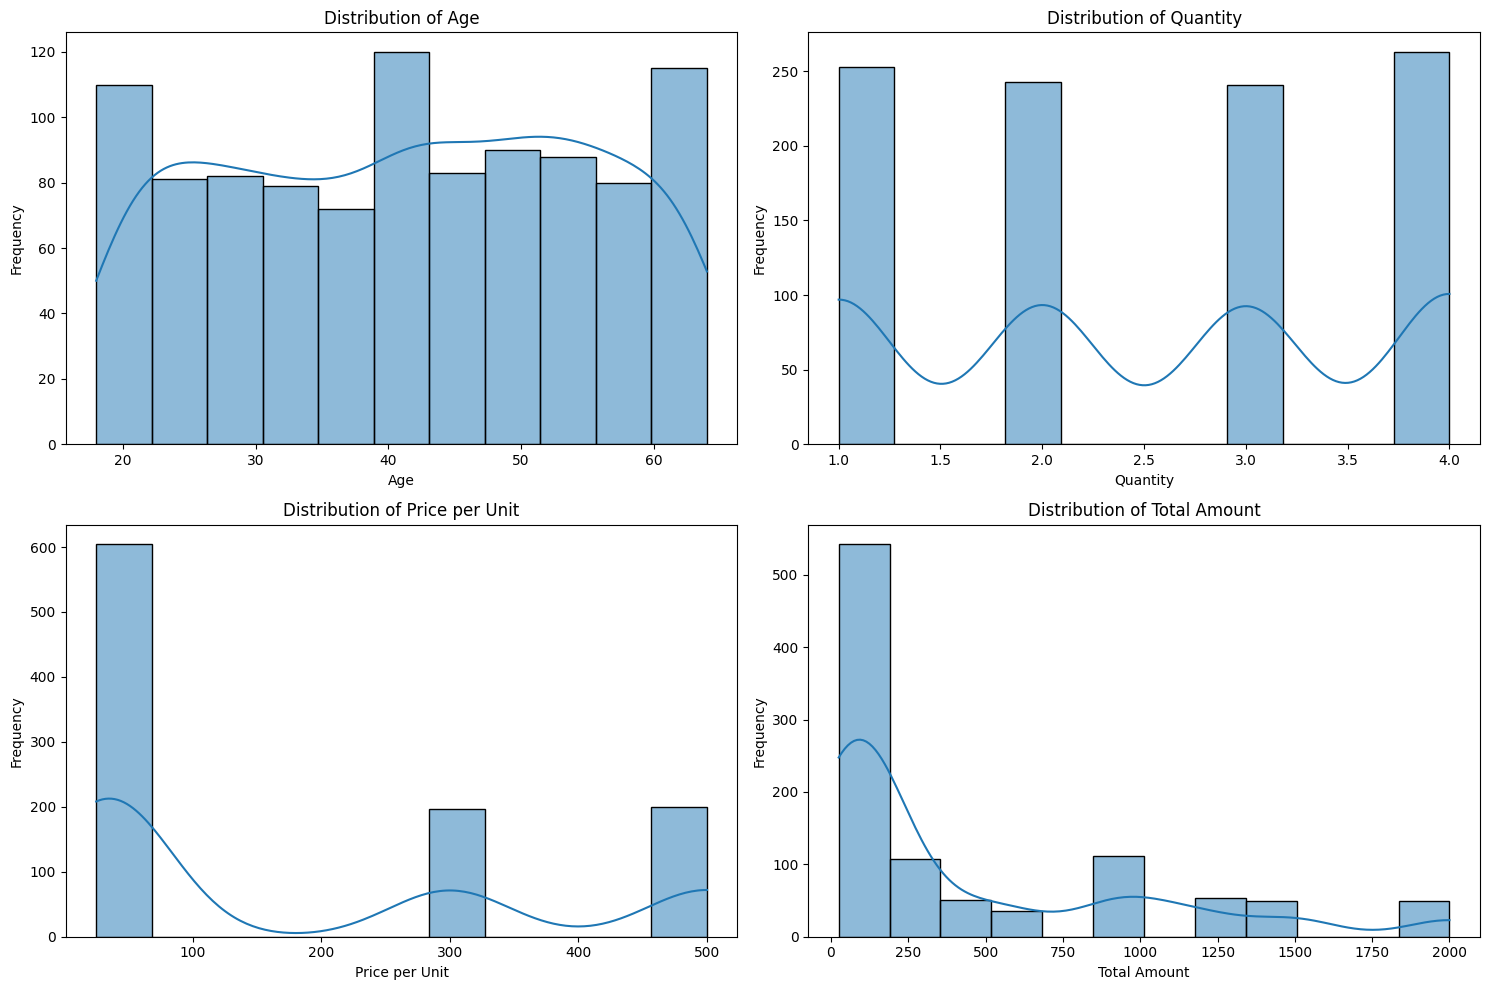

In [ ]:
numerical_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

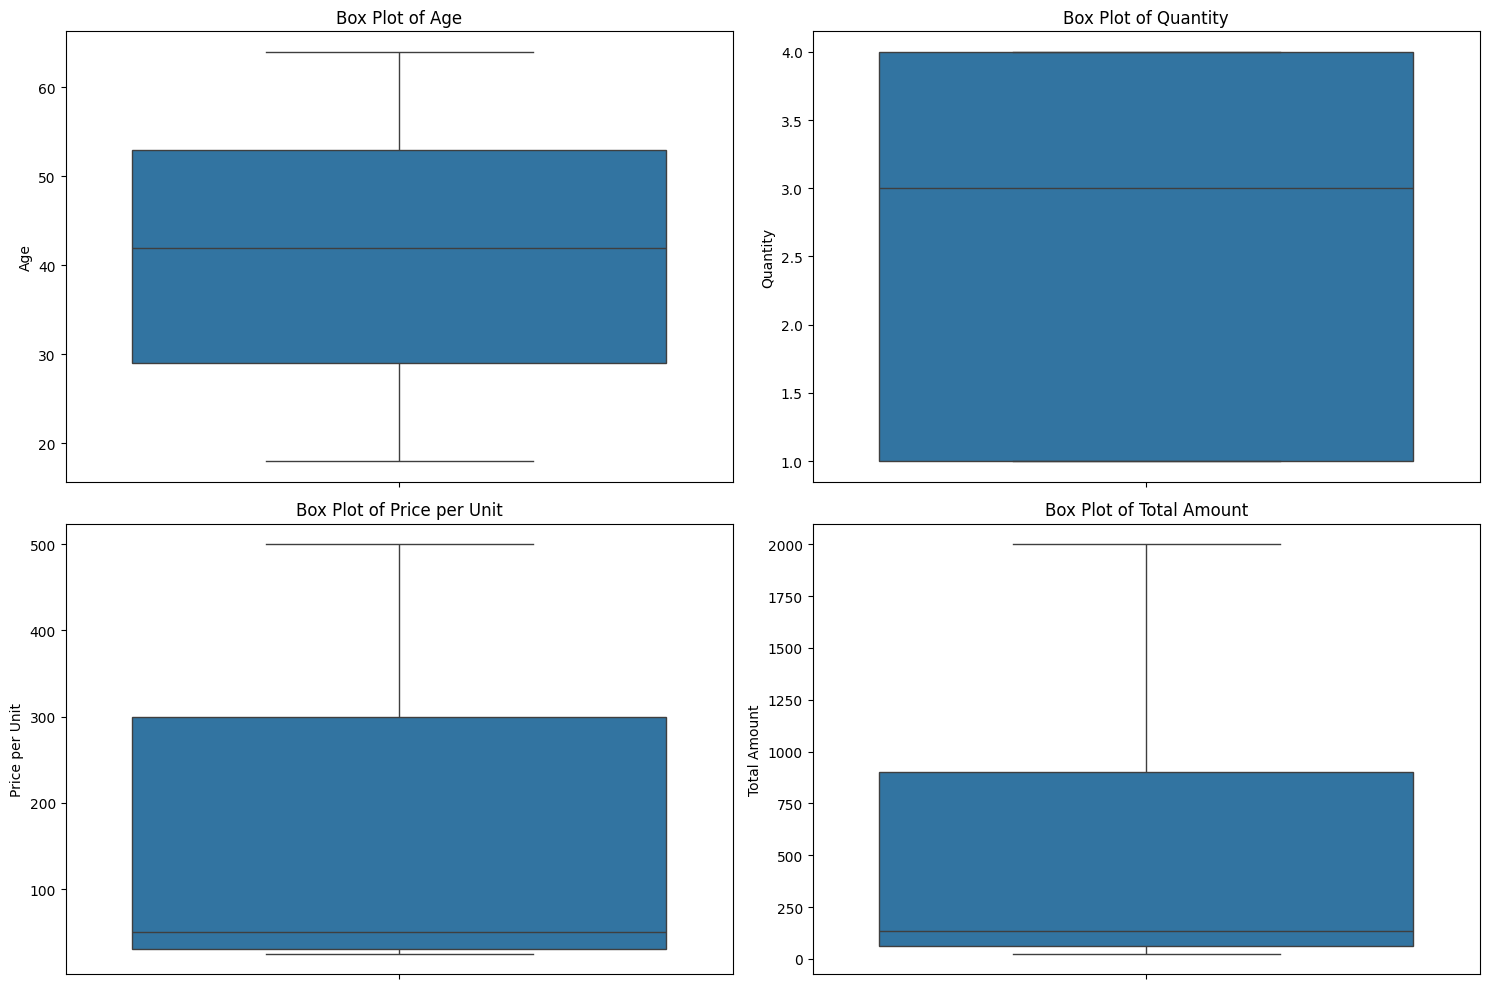

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### Distribution of Categorical Features

Now, let's visualize the distribution of categorical features using count plots.

/tmp/ipykernel_1130/72752706.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_1130/72752706.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


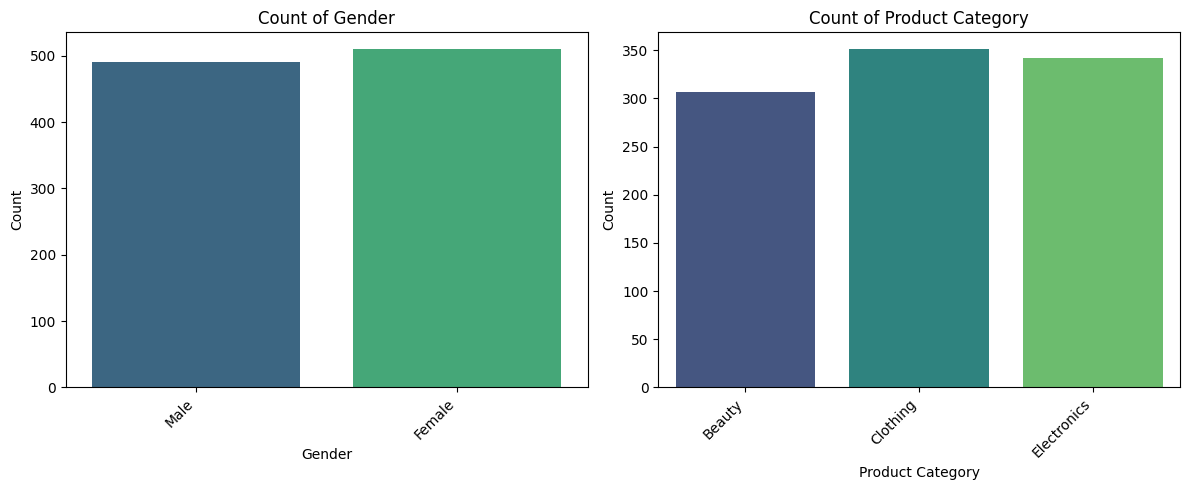

In [ ]:
categorical_cols = ['Gender', 'Product Category']

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i + 1) # Arrange plots in a 1x2 grid
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Bivariate Analysis

Now, let's explore the relationships between pairs of variables in the dataset.

### Correlation Matrix of Numerical Features

We will use a heatmap to visualize the correlation matrix of numerical features, which helps identify strong positive or negative relationships.

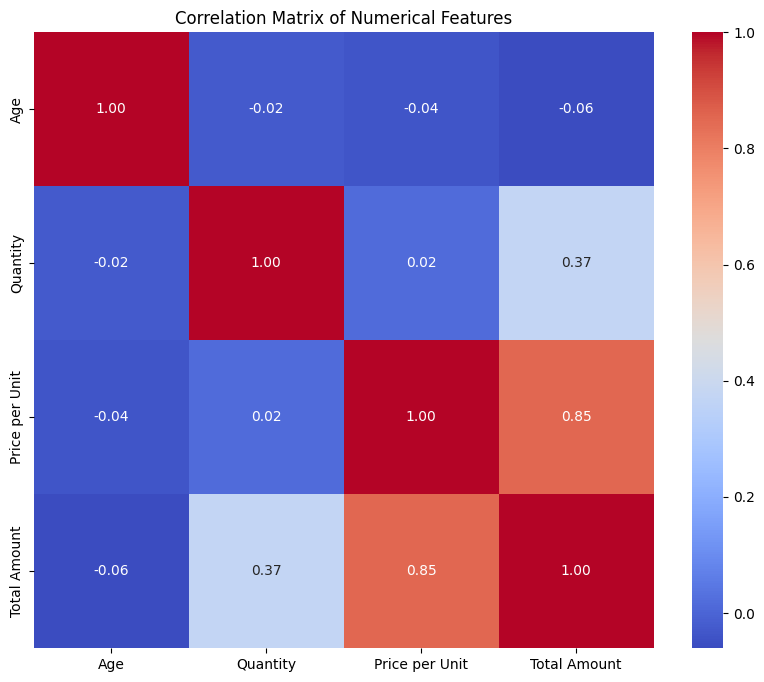

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Numerical vs. Categorical Features

Let's visualize the relationship between numerical features and categorical features using box plots to compare distributions across different groups.

/tmp/ipykernel_1130/3645220814.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='Total Amount', palette='viridis')
/tmp/ipykernel_1130/3645220814.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Product Category', y='Total Amount', palette='plasma')


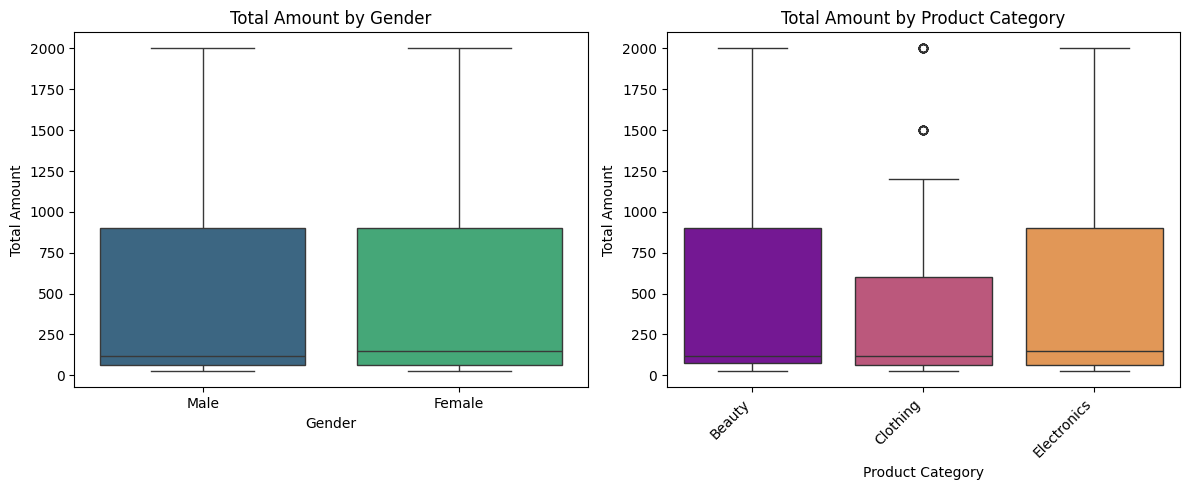

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Gender', y='Total Amount', palette='viridis')
plt.title('Total Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Amount')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Product Category', y='Total Amount', palette='plasma')
plt.title('Total Amount by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Categorical vs. Categorical Features

Finally, let's explore the relationship between two categorical features using a stacked bar chart or a count plot with hue.

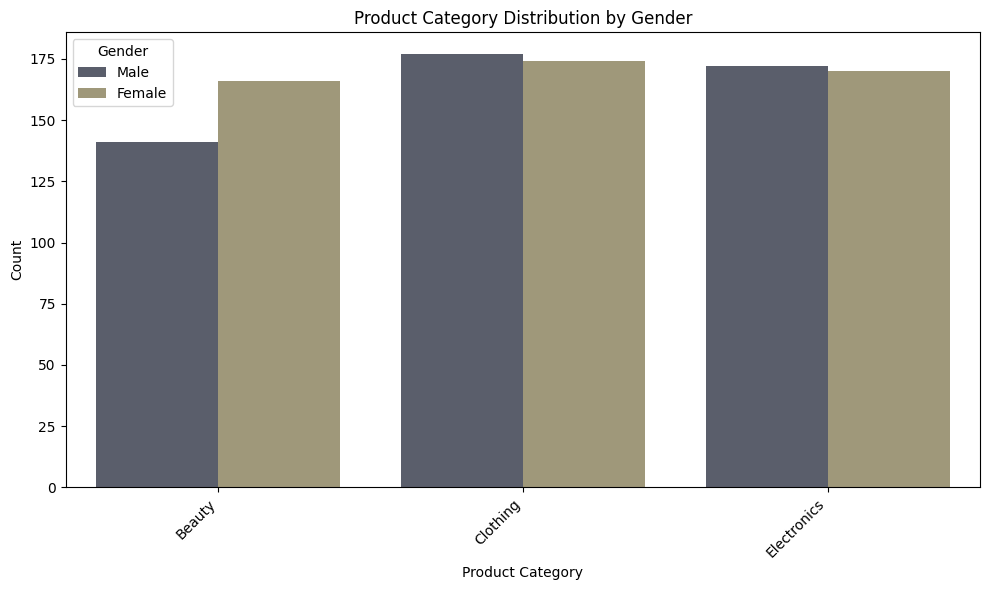

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Product Category', hue='Gender', palette='cividis')
plt.title('Product Category Distribution by Gender')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

### Sales Trend by Product Category

Let's visualize the trend of 'Total Amount' over 'Date', separated by 'Product Category', to observe how sales of different product types evolve over time.

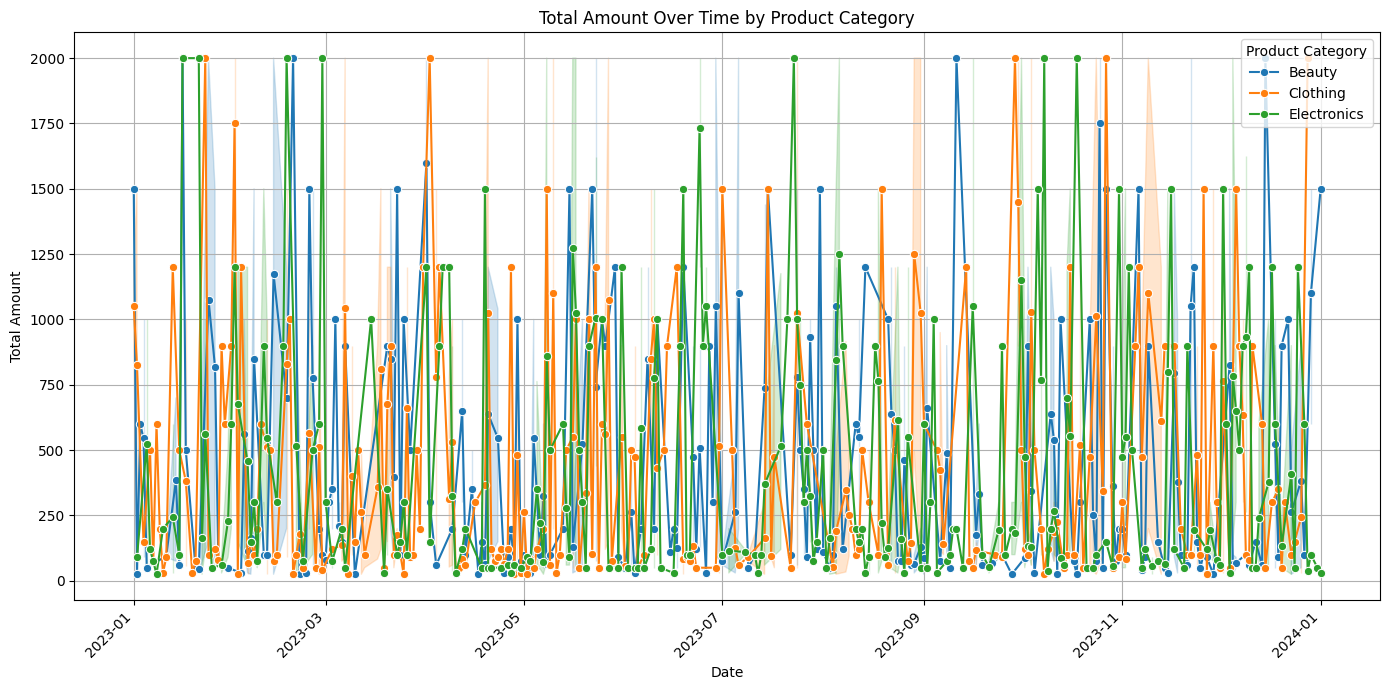

In [ ]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x='Date', y='Total Amount', hue='Product Category', marker='o')
plt.title('Total Amount Over Time by Product Category')
plt.xlabel('Date')
plt.ylabel('Total Amount')
plt.grid(True)
plt.legend(title='Product Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Bubble Chart: Price, Quantity, and Total Amount by Product Category

This bubble chart will help us understand the relationship between 'Price per Unit', 'Quantity', and 'Total Amount', with the 'Product Category' providing an additional layer of information through color. The size of each bubble will represent the 'Total Amount'.

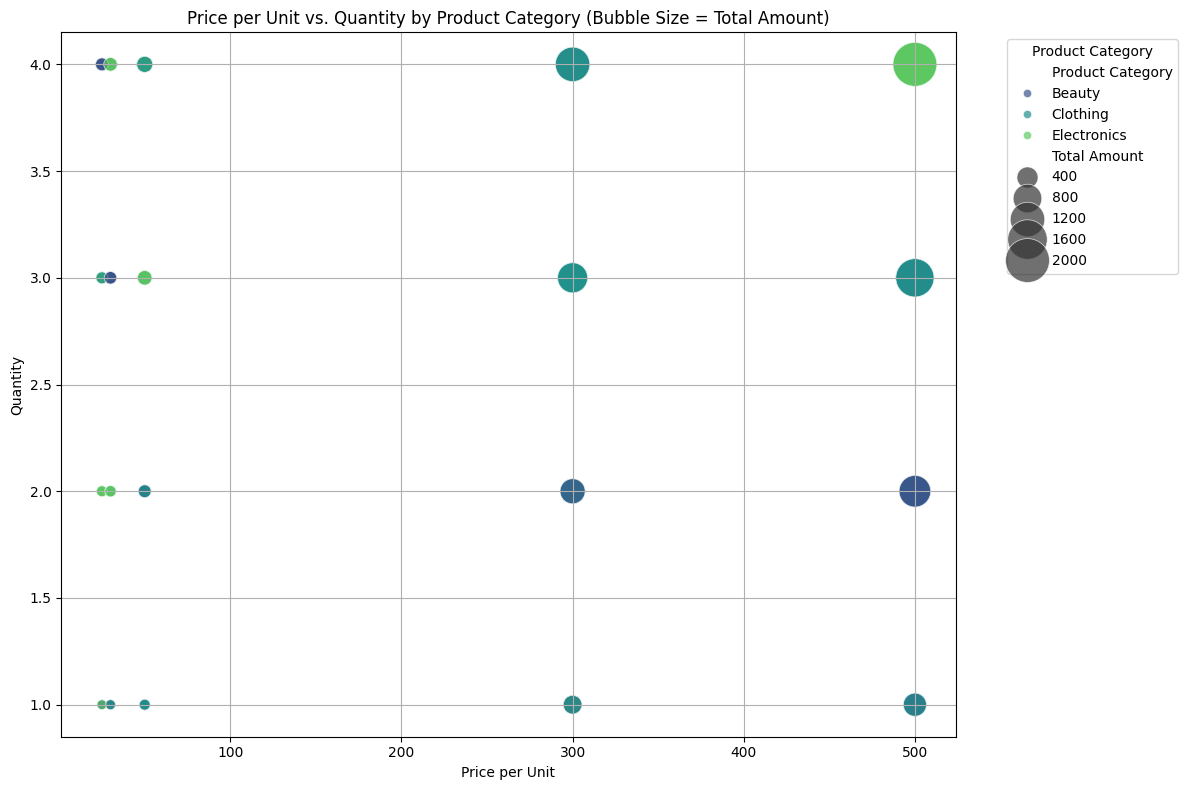

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Price per Unit', y='Quantity', size='Total Amount', hue='Product Category', sizes=(50, 1000), alpha=0.7, palette='viridis')
plt.title('Price per Unit vs. Quantity by Product Category (Bubble Size = Total Amount)')
plt.xlabel('Price per Unit')
plt.ylabel('Quantity')
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

## Multivariate Analysis

Let's now explore relationships among three or more variables to uncover more complex patterns.

### Pair Plot of Numerical Features by Gender

A pair plot visualizes pairwise relationships between numerical variables and also shows the distribution of each variable. We will use 'Gender' as a hue to see if relationships differ by gender.

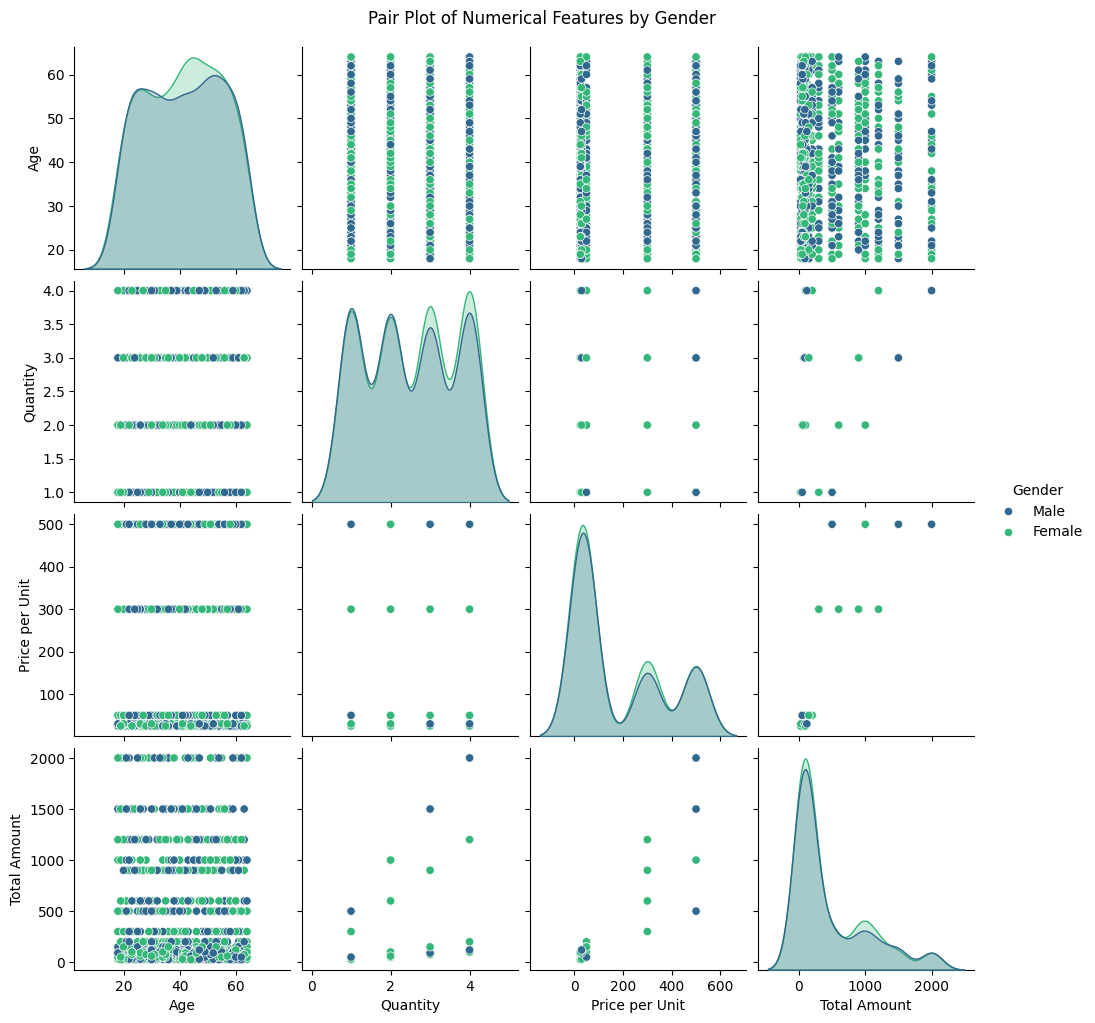

In [ ]:
sns.pairplot(df, vars=numerical_cols, hue='Gender', palette='viridis', diag_kind='kde')
plt.suptitle('Pair Plot of Numerical Features by Gender', y=1.02) # Adjust suptitle position
plt.show()

### Pair Plot of Numerical Features by Product Category

Similarly, let's observe the pairwise relationships by 'Product Category' to see if different product types exhibit distinct patterns in numerical features.

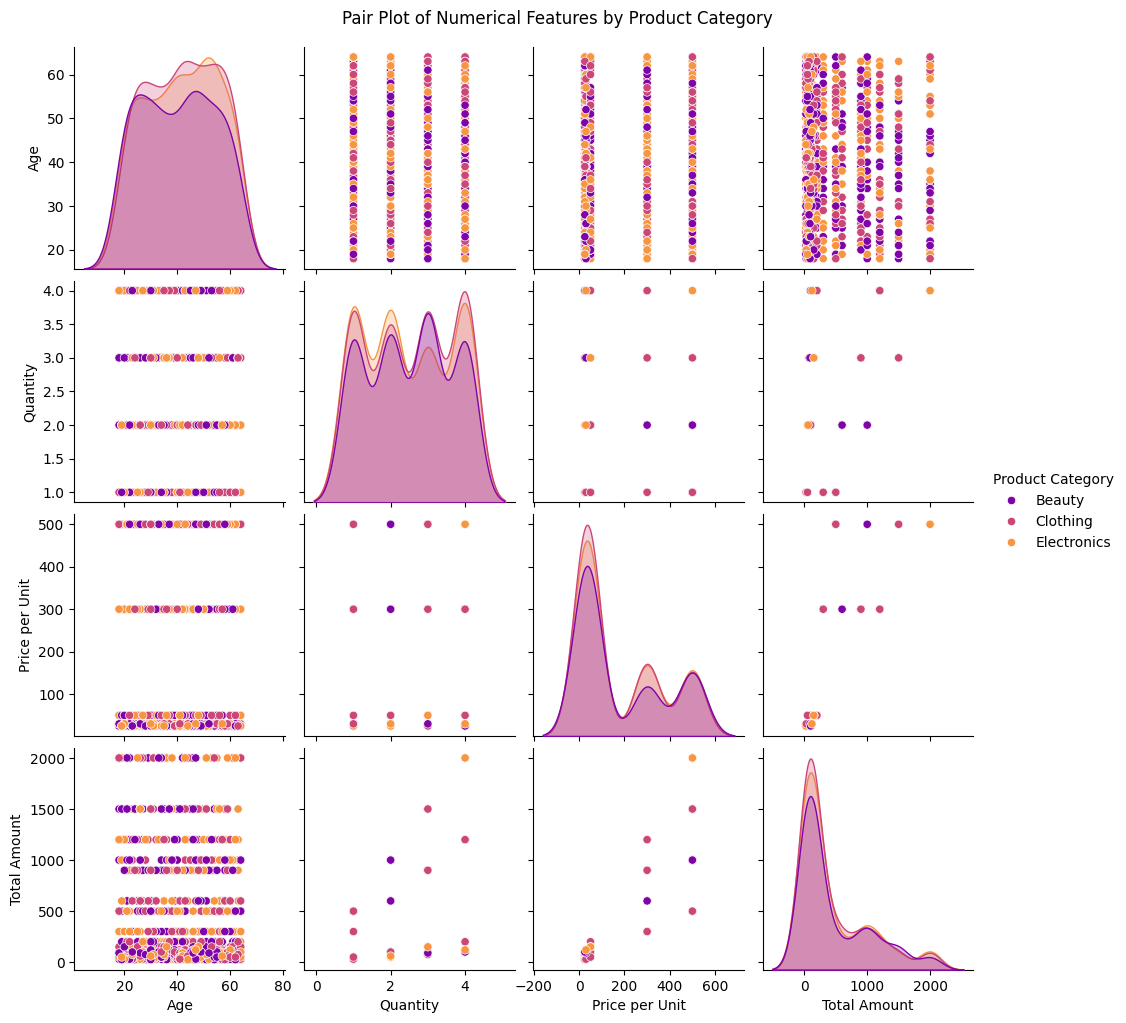

In [ ]:
sns.pairplot(df, vars=numerical_cols, hue='Product Category', palette='plasma', diag_kind='kde')
plt.suptitle('Pair Plot of Numerical Features by Product Category', y=1.02) # Adjust suptitle position
plt.show()